# 🏦 CFO Agent — SFT Training (Gemma 2 9B)

Single-agent **Supervised Fine-Tuning** for the CFO decision-maker.  
The other three agents (Expenditure, Revenue, Risk) are handled via ICL separately.

**Base Model**: `unsloth/gemma-2-9b-it-bnb-4bit`  
**Method**: QLoRA (4-bit) with Unsloth  
**Hardware**: ≥24 GB VRAM recommended (A100/H100/L4)


## 1. Install Dependencies

In [1]:
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" \
    datasets trl matplotlib pandas huggingface_hub python-dotenv


## 2. Configuration

In [ ]:
import os, json, inspect, torch
import matplotlib.pyplot as plt
from datasets import Dataset
from huggingface_hub import login
from dotenv import load_dotenv
os.environ["TORCH_COMPILE_DISABLE"] = "1" # ✅ Ensure Dynamo crashes are prevented
load_dotenv()
HF_TOKEN = os.environ.get("HF_TOKEN", "")
if HF_TOKEN:
    login(token=HF_TOKEN)
# ── Changed from Gemma to Llama 3.2 (T4 Compatible) ──
MODEL_NAME     = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"
# ── Important: Must use Llama's specific chat template ──
CHAT_TEMPLATE  = "llama-3.1"
MAX_SEQ_LENGTH = 2048
LORA_R         = 32
LORA_ALPHA     = 32
BATCH_SIZE     = 2       
GRAD_ACCUM     = 4
MAX_STEPS      = 100
LEARNING_RATE  = 1e-4
WARMUP_RATIO   = 0.05
WEIGHT_DECAY   = 0.01
BASE_PATH  = "/teamspace/studios/this_studio/Cashflowmanager"
DATA_PATH  = f"{BASE_PATH}/data/cfo_sft.jsonl"
OUTPUT_DIR = "outputs/cfo"
os.makedirs(OUTPUT_DIR, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"GPU  : {torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU'}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if device == "cuda" else "")
print(f"Model: {MODEL_NAME}")
print(f"Data : {DATA_PATH}")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


GPU  : Tesla T4
VRAM : 15.6 GB
Model: unsloth/Llama-3.2-3B-Instruct-bnb-4bit
Data : /teamspace/studios/this_studio/Cashflowmanager/data/cfo_sft.jsonl


## 3. Inspect CFO Training Data

In [3]:
with open(DATA_PATH) as f:
    lines = f.readlines()

print(f"Total samples: {len(lines)}")

sample = json.loads(lines[0])
print(f'\n{"="*60}')
print("System prompt:")
print(sample["messages"][0]["content"])
print(f'\n{"─"*60}')
print("User input (first 300 chars):")
print(sample["messages"][1]["content"][:300])
print(f'\n{"─"*60}')
print("Expected output:")
print(sample["messages"][2]["content"])


Total samples: 3000

System prompt:
You are the CFO of a company managing daily cash flow decisions.
You receive memos from three advisors:
- Expenditure Agent: payment priorities
- Revenue Agent: cash inflow projections
- Risk Agent: threat assessment

Based on their advice and the current financial state, decide the action for each invoice.

You must output a JSON object with:
- "actions": list of {"invoice_id": "...", "type": "pay|defer|partial|negotiate|credit", "amount": float, "reasoning": "..."}
- "overall_strategy": 1-2 sentence explanation of your approach
- "confidence": float 0.0-1.0

Rules:
- You CANNOT spend more cash than available (cash + remaining credit)
- Balance between paying urgent invoices and maintaining reserves
- Use negotiate when vendor trust is high and you need relief
- Use credit only when necessary — it reduces your score
- Consider advisor warnings seriously

────────────────────────────────────────────────────────────
User input (first 300 chars):
Day: 

## 4. Train CFO Agent

In [4]:
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template
from trl import SFTTrainer, SFTConfig
from transformers import TrainerCallback
class LossLogger(TrainerCallback):
    def __init__(self):
        self.losses, self.steps = [], []
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.losses.append(logs["loss"])
            self.steps.append(state.global_step)
# ── Load model ──
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)
tokenizer = get_chat_template(tokenizer, chat_template=CHAT_TEMPLATE)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
# ── Attach LoRA ──
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=LORA_ALPHA,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)
# ── Build dataset ──
with open(DATA_PATH) as f:
    raw = [json.loads(l.strip()) for l in f if l.strip()]
print(f"Loaded {len(raw)} CFO samples")
dataset = Dataset.from_list(raw)
dataset = dataset.map(
    lambda ex: {"text": [
        tokenizer.apply_chat_template(m, tokenize=False, add_generation_prompt=False)
        for m in ex["messages"]
    ]},
    batched=True,
    remove_columns=dataset.column_names,
)
# ── SFTConfig (filter to valid fields) ──
valid_args = set(inspect.signature(SFTConfig.__init__).parameters.keys())
sft_kwargs = {k: v for k, v in {
    "output_dir"                  : OUTPUT_DIR,
    "per_device_train_batch_size" : BATCH_SIZE,
    "gradient_accumulation_steps" : GRAD_ACCUM,
    "warmup_ratio"                : WARMUP_RATIO,
    "max_steps"                   : MAX_STEPS,
    "learning_rate"               : LEARNING_RATE,
    "fp16"                        : not torch.cuda.is_bf16_supported(),
    "bf16"                        : torch.cuda.is_bf16_supported(),
    "logging_steps"               : 10,
    "save_steps"                  : MAX_STEPS,
    "optim"                       : "adamw_8bit",
    "weight_decay"                : WEIGHT_DECAY,
    "lr_scheduler_type"           : "cosine",
    "seed"                        : 42,
    "report_to"                   : "none",
    "dataset_text_field"          : "text",
    "max_seq_length"              : MAX_SEQ_LENGTH,
    "dataset_num_proc"            : 2,
}.items() if k in valid_args}
logger  = LossLogger()
trainer = SFTTrainer(
    model=model, tokenizer=tokenizer,
    train_dataset=dataset,
    args=SFTConfig(**sft_kwargs),
    callbacks=[logger],
)
print(f"\nTraining CFO agent on {MODEL_NAME} ...")
stats = trainer.train()
print(f"\n✅ Final loss: {stats.training_loss:.4f}")
# ── Save LoRA adapter ──
model.save_pretrained_merged(OUTPUT_DIR, tokenizer, save_method="lora")
print(f"💾 LoRA adapter saved → {OUTPUT_DIR}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Loaded 3000 CFO samples


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [00:27<00:00, 13.56s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [00:26<00:00, 13.47s/it]


Unsloth: Merge process complete. Saved to `/teamspace/studios/this_studio/Cashflowmanager/notebooks/outputs/cfo`
💾 LoRA adapter saved → outputs/cfo


## 5. Loss Curve

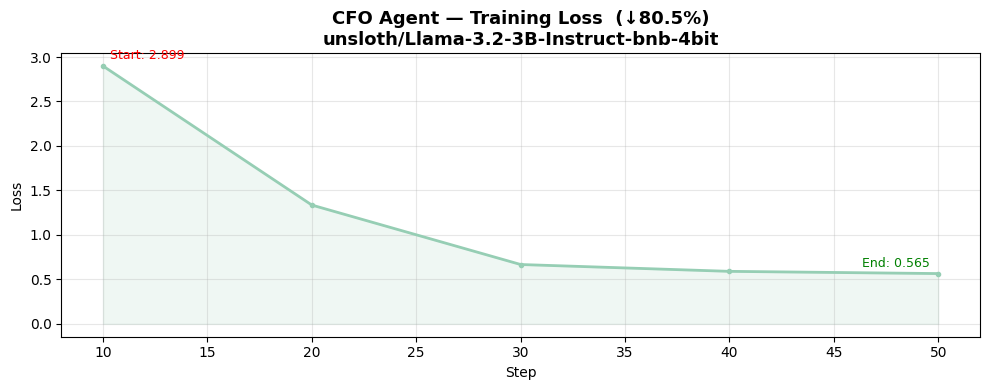

📈 Saved → cfo_loss_curve.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(logger.steps, logger.losses, color="#96CEB4", linewidth=2, marker="o", markersize=3)
ax.fill_between(logger.steps, logger.losses, alpha=0.15, color="#96CEB4")
if logger.losses:
    reduction = (1 - logger.losses[-1] / logger.losses[0]) * 100
    ax.annotate(f"Start: {logger.losses[0]:.3f}", xy=(logger.steps[0], logger.losses[0]),
                xytext=(5, 5), textcoords="offset points", fontsize=9, color="red")
    ax.annotate(f"End: {logger.losses[-1]:.3f}", xy=(logger.steps[-1], logger.losses[-1]),
                xytext=(-55, 5), textcoords="offset points", fontsize=9, color="green")
    ax.set_title(f"CFO Agent — Training Loss  (↓{reduction:.1f}%)\n{MODEL_NAME}",
                 fontsize=13, fontweight="bold")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cfo_loss_curve.png", dpi=150)
plt.show()
print("📈 Saved → cfo_loss_curve.png")


## 6. Before vs After: CFO Response Comparison

In [6]:
import os, re, time, gc
from peft import PeftModel

os.environ["TORCH_COMPILE_DISABLE"] = "1"
OUTPUT_DIR = "/teamspace/studios/this_studio/Cashflowmanager/notebooks/outputs/cfo/checkpoint-50"

CFO_SYSTEM = (
    "You are the CFO of a company managing daily cash flow decisions. "
    "Output valid JSON with keys: invoice_id, type (pay|defer|negotiate|credit), "
    "amount, reasoning."
)
TEST_PROMPT = (
    "Day: 3 | Cash: ₹150000 | Credit: ₹0/500000\n\n"
    "ADVISORS:\n"
    "[Expenditure]: [PAY_IMMEDIATELY] Invoice abc123 has penalty cost ₹8500. Pay immediately.\n"
    "[Revenue]: [CASH_TIGHT] Deficit of ₹50000 expected. Draw credit immediately.\n"
    "[Risk]: [HIGH] Credit: 0%. 2 threats detected. Build cash reserves.\n\n"
    "INVOICES:\n- abc123: ₹120000 due 1d\n- def456: ₹300000 due 5d"
)


def run_inference(mdl, tok, max_new_tokens=300):
    msgs = [{"role": "system", "content": CFO_SYSTEM},
            {"role": "user",   "content": TEST_PROMPT}]
    inp = tok.apply_chat_template(
        msgs, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    t0 = time.time()
    with torch.no_grad():
        out = mdl.generate(
            input_ids=inp, max_new_tokens=max_new_tokens,
            do_sample=False, repetition_penalty=1.15, use_cache=True
        )
    return tok.decode(out[0][inp.shape[1]:], skip_special_tokens=True).strip(), time.time() - t0


def check_json(text, label):
    try:
        parsed = json.loads(re.sub(r"^[^{\[]*", "", text))
        keys = list(parsed.keys()) if isinstance(parsed, dict) else type(parsed)
        print(f"  {label}: ✅ valid JSON — keys: {keys}")
    except Exception as e:
        print(f"  {label}: ❌ not valid JSON ({e})")


# ─────────────────────────────────────────────────────────────────────────────
# Load the model ONCE — run base inference first, then attach adapter
# This avoids the double-load OOM that caused the ValueError
# ─────────────────────────────────────────────────────────────────────────────
print("Loading model (single load for both inferences) ...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)
tokenizer = get_chat_template(tokenizer, chat_template=CHAT_TEMPLATE)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ── 1. Base inference (no adapter) ───────────────────────────────────────────
FastLanguageModel.for_inference(model)
print("\nRunning base model inference ...")
base_resp, base_lat = run_inference(model, tokenizer)

# ── 2. Attach LoRA adapter in-place, re-run inference ────────────────────────
# Disable cache before wrapping with PeftModel
model.config.use_cache = False
trained_model = PeftModel.from_pretrained(model, OUTPUT_DIR, is_trainable=False)
FastLanguageModel.for_inference(trained_model)
print("Adapter attached. Running trained model inference ...")
train_resp, train_lat = run_inference(trained_model, tokenizer)

# ── Cleanup ───────────────────────────────────────────────────────────────────
del trained_model, model
torch.cuda.empty_cache(); gc.collect()

# ── Results ───────────────────────────────────────────────────────────────────
print(f'\n{"="*60}\n🔴 BASE MODEL  (latency: {base_lat:.2f}s)\n{"="*60}')
print(base_resp)
print(f'\n{"="*60}\n🟢 TRAINED CFO (latency: {train_lat:.2f}s)\n{"="*60}')
print(train_resp)

print("\n── JSON validity ──")
check_json(base_resp,  "Base   ")
check_json(train_resp, "Trained")

Loading model (single load for both inferences) ...
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Running base model inference ...


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/

Adapter attached. Running trained model inference ...

🔴 BASE MODEL  (latency: 11.42s)
```json
{
    "invoices": [
        {
            "invoice_id": "abc123",
            "type": "pay",
            "amount": 120000,
            "reasoning": "Penalty cost ₹8500"
        },
        {
            "invoice_id": "def456",
            "type": "defer",
            "amount": 300000,
            "reasoning": ""
        }
    ],
    "cash": {
        "current": 150000,
        "available_credit": 500000
    }
}
```

Explanation:

*   We have two invoices to process today (`abc123` and `def456`). 
*   For `abc123`, we need to pay the full amount as there is no discount mentioned in the advisors. The reason for this payment is that it comes with a penalty cost of ₹8500.
*   For `def456`, since its due date is far away (5 days from now) and our current deficit is relatively low compared to other options available, we can defer paying this amount until later. This decision was made based on the ad